# Data Verzameling & Verkenning (EDA)
**Groep 2 | Hogeschool van Amsterdam | 2024-2025**

Dit notebook heeft twee doelen:
1. **Data verzameling** — controleren of de API-URLs bereikbaar zijn en data teruggeven
2. **EDA (Exploratory Data Analysis)** — de data bekijken, testen en opschonen

---

## 0. Bibliotheken importeren

We importeren de Python-pakketten die we nodig hebben.
- `requests` → voor het ophalen van data via APIs
- `pandas` → voor het werken met tabellen (DataFrames)
- `numpy` → voor wiskundige berekeningen
- `matplotlib` / `seaborn` → voor grafieken

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# mooiere grafieken
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print('Alle bibliotheken geladen ✓')

Alle bibliotheken geladen ✓


---
## 1. DATA VERZAMELING — API-URLs controleren

We gebruiken twee APIs:
| # | Bron | URL |
|---|------|-----|
| 1 | CBS Kerncijfers Wijken & Buurten | `https://opendata.cbs.nl/ODataApi/odata/85984NED/TypedDataSet` |
| 2 | DUO Schooladviezen (wpoadvies-v1) | `https://onderwijsdata.duo.nl/api/3/action/package_show` |

Voor elke API controleren we:
- Reageert de server? (HTTP-statuscode)
- Hoe snel? (responstijd)
- Geeft de server data terug? (eerste paar rijen)

In [2]:
def test_api(naam, url, params=None, verwacht_veld=None):
    """Test een API-URL en rapporteer de bevindingen."""
    print(f"\n{'='*60}")
    print(f"API: {naam}")
    print(f"URL: {url}")
    if params:
        print(f"Parameters: {params}")
    print()

    start = time.time()
    try:
        antwoord = requests.get(url, params=params, timeout=20)
        duur = round(time.time() - start, 2)

        # HTTP-statuscode
        code = antwoord.status_code
        if code == 200:
            print(f"✅ HTTP {code} — server bereikbaar (in {duur}s)")
        elif code in (301, 302):
            print(f"↪️  HTTP {code} — doorverwijzing (in {duur}s)")
        else:
            print(f"❌ HTTP {code} — fout! (in {duur}s)")
            return None

        # inhoud controleren
        try:
            data = antwoord.json()
            if verwacht_veld and verwacht_veld in data:
                items = data[verwacht_veld]
                print(f"✅ JSON ontvangen — '{verwacht_veld}' bevat {len(items)} rijen")
                if len(items) > 0 and isinstance(items[0], dict):
                    print(f"   Kolommen: {list(items[0].keys())[:8]} ...")
            else:
                sleutels = list(data.keys()) if isinstance(data, dict) else type(data).__name__
                print(f"✅ JSON ontvangen — sleutels: {sleutels}")
            return data
        except Exception:
            print(f"⚠️  Antwoord is geen JSON (lengte: {len(antwoord.text)} tekens)")
            return antwoord.text

    except requests.exceptions.Timeout:
        print(f"❌ TIMEOUT — server reageert niet binnen 20 seconden")
        return None
    except requests.exceptions.ConnectionError as e:
        print(f"❌ VERBINDINGSFOUT — {e}")
        return None
    except Exception as e:
        print(f"❌ ONBEKENDE FOUT — {e}")
        return None

### 1.1 CBS OData v3 API testen

In [3]:
cbs_url    = "https://opendata.cbs.nl/ODataApi/odata/85984NED/TypedDataSet"
cbs_params = {
    "$filter": "startswith(WijkenEnBuurten,'WK0363')",  # alleen Amsterdam-wijken
    "$format": "json",
    "$top": 5   # maar 5 rijen om snel te testen
}

cbs_resultaat = test_api("CBS Kerncijfers Wijken & Buurten 2024", cbs_url, cbs_params, "value")


API: CBS Kerncijfers Wijken & Buurten 2024
URL: https://opendata.cbs.nl/ODataApi/odata/85984NED/TypedDataSet
Parameters: {'$filter': "startswith(WijkenEnBuurten,'WK0363')", '$format': 'json', '$top': 5}

✅ HTTP 200 — server bereikbaar (in 0.12s)
✅ JSON ontvangen — 'value' bevat 5 rijen
   Kolommen: ['ID', 'WijkenEnBuurten', 'Gemeentenaam_1', 'SoortRegio_2', 'Codering_3', 'IndelingswijzigingGemeenteWijkBuurt_4', 'AantalInwoners_5', 'Mannen_6'] ...


In [4]:
# CBS: bekijk de eerste rij als tabel
if cbs_resultaat and 'value' in cbs_resultaat and len(cbs_resultaat['value']) > 0:
    cbs_sample = pd.DataFrame(cbs_resultaat['value'])
    print(f"Aantal rijen teruggegeven: {len(cbs_sample)}")
    print(f"Aantal kolommen: {len(cbs_sample.columns)}")
    print("\nEerste rij (geselecteerde kolommen):")
    
    # toon de meest relevante kolommen
    interessant = [c for c in cbs_sample.columns
                   if any(w in c.lower() for w in ['wijken', 'inwoners', 'inkomen', 'woz', 'bijstand', 'hbo', 'basis'])]
    display(cbs_sample[interessant].head(3))
else:
    print("⚠️ Geen CBS-data ontvangen — we gebruiken eigen nooddata")

Aantal rijen teruggegeven: 5
Aantal kolommen: 123

Eerste rij (geselecteerde kolommen):


,WijkenEnBuurten,AantalInwoners_5,GemiddeldeWOZWaardeVanWoningen_39,StudentenHbo_65,BasisonderwijsVmboMbo1_67,HboWo_69,AantalInkomensontvangers_76,GemiddeldInkomenPerInkomensontvanger_77,GemiddeldInkomenPerInwoner_78,k_40PersonenMetLaagsteInkomen_79,k_20PersonenMetHoogsteInkomen_80,GemGestandaardiseerdInkomen_83,k_40HuishoudensMetLaagsteInkomen_84,k_20HuishoudensMetHoogsteInkomen_85,PersonenPerSoortUitkeringBijstand_87
0,WK0363AA,9180,610,180,960.0,4960,7800,53.9,47.3,37.3,29.4,49.3,49.7,18.1,280
1,WK0363AB,19685,550,500,2020.0,10390,17100,51.4,45.8,38.8,26.7,45.8,56.3,14.5,660
2,WK0363AC,6630,909,170,610.0,3920,5400,75.8,65.8,32.6,37.8,87.4,42.4,27.2,30


### 1.2 DUO Open Onderwijsdata API testen

In [5]:
duo_url    = "https://onderwijsdata.duo.nl/api/3/action/package_show"
duo_params = {"id": "wpoadvies-v1"}

duo_resultaat = test_api("DUO Schooladviezen (wpoadvies-v1)", duo_url, duo_params)


API: DUO Schooladviezen (wpoadvies-v1)
URL: https://onderwijsdata.duo.nl/api/3/action/package_show
Parameters: {'id': 'wpoadvies-v1'}



✅ HTTP 200 — server bereikbaar (in 0.13s)
✅ JSON ontvangen — sleutels: ['help', 'success', 'result']


In [6]:
# DUO: welke bestanden zijn beschikbaar?
if duo_resultaat and isinstance(duo_resultaat, dict):
    package = duo_resultaat.get('result', {})
    bronnen = package.get('resources', [])
    print(f"Beschrijving dataset: {package.get('notes', 'geen')[:200]}")
    print(f"\nAantal beschikbare bestanden: {len(bronnen)}")
    for b in bronnen:
        print(f"  - [{b.get('format','?')}] {b.get('name','?')}")
        print(f"    URL: {b.get('url','?')[:80]}...")

    # probeer de CSV te downloaden
    csvs = [b for b in bronnen if b.get('format','').upper() == 'CSV']
    if csvs:
        print(f"\n→ CSV gevonden, downloaden...")
        try:
            r = requests.get(csvs[0]['url'], timeout=30)
            from io import StringIO
            # probeer komma en puntkomma als scheidingsteken
            for sep in [';', ',']:
                try:
                    df_duo_live = pd.read_csv(StringIO(r.text), sep=sep, encoding='latin-1', nrows=5)
                    if len(df_duo_live.columns) > 2:
                        break
                except:
                    continue
            print(f"✅ CSV geladen — kolommen: {list(df_duo_live.columns)}")
            display(df_duo_live.head(3))
        except Exception as e:
            print(f"❌ CSV downloaden mislukt: {e}")

Beschrijving dataset: ## Leerlingen_WPO_advies
Leerlingen bo en sbo per vestiging naar advies
## Inleiding
Dit document beschrijft de bestanden over leerlingen in het Primair Onderwijs die via een API (Application Progr

Aantal beschikbare bestanden: 1
  - [CSV] Leerlingen bo en sbo per vestiging naar advies
    URL: https://onderwijsdata.duo.nl/dataset/d6903313-8c64-4b12-b4ac-07e5655ef9f4/resour...

→ CSV gevonden, downloaden...


✅ CSV geladen — kolommen: ['INSTELLINGSCODE', 'VESTIGINGSCODE', 'TYPE_PO', 'PEILJAAR', 'ADVIES', 'AANTAL_LEERLINGEN']


,INSTELLINGSCODE,VESTIGINGSCODE,TYPE_PO,PEILJAAR,ADVIES,AANTAL_LEERLINGEN
0,00AP,0,BO,2010,7,-1
1,00AP,0,BO,2010,9,-1
2,00AP,0,BO,2010,10,-1


### 1.3 Conclusie data verzameling

Hieronder vatten we samen welke APIs werken en welke niet, en wat we doen als een API niet beschikbaar is.

In [7]:
print("=" * 60)
print("CONCLUSIE DATA VERZAMELING")
print("=" * 60)
print()
print("CBS OData API (opendata.cbs.nl):")
if cbs_resultaat and 'value' in cbs_resultaat:
    print("  ✅ Bereikbaar en geeft data terug")
    print("  ⚠️ Wijk-codes in v3 (bijv. WK0363AA) zijn ANDERS dan in onze nooddata")
    print("     → We gebruiken nooddata zodat alles consistent is")
else:
    print("  ❌ Niet bereikbaar")
    print("  → We gebruiken nooddata (gebaseerd op echte CBS-cijfers 2023)")

print()
print("DUO Open Onderwijsdata:")
if duo_resultaat:
    print("  ✅ API zelf bereikbaar")
    print("  ⚠️ CSV-formaat is veranderd: geen PLAATSNAAM/wijk_code meer")
    print("  → We gebruiken nooddata (gebaseerd op echte DUO-verhoudingen 2018-2024)")
else:
    print("  ❌ Niet bereikbaar")
    print("  → We gebruiken nooddata")

CONCLUSIE DATA VERZAMELING

CBS OData API (opendata.cbs.nl):
  ✅ Bereikbaar en geeft data terug
  ⚠️ Wijk-codes in v3 (bijv. WK0363AA) zijn ANDERS dan in onze nooddata
     → We gebruiken nooddata zodat alles consistent is

DUO Open Onderwijsdata:
  ✅ API zelf bereikbaar
  ⚠️ CSV-formaat is veranderd: geen PLAATSNAAM/wijk_code meer
  → We gebruiken nooddata (gebaseerd op echte DUO-verhoudingen 2018-2024)


---
## 2. DATA VERKENNING (EDA)

Nu laden we de data die het dashboard gebruikt en bekijken we die grondig.

**EDA = Exploratory Data Analysis.** Dat betekent:
- Hoe groot is de dataset? (rijen × kolommen)
- Welke kolommen zijn er en wat zijn de datatypes?
- Zijn er ontbrekende waarden?
- Hoe zijn de waarden verdeeld? (minimum, maximum, gemiddelde)
- Zijn er vreemde/verdachte waarden?

In [8]:
import sys
sys.path.insert(0, r'c:\Users\AAchr\Documents\Casus 2 phyton minor\ROC')
from data import laad_alle_data, ADVIES_TYPEN, ADVIES_KLEUREN, SCHOOLJAREN

wijken_df, duo_df, bronnen = laad_alle_data()

print("Data geladen!")
print()
print("Gebruikte databronnen:")
for naam, bron in bronnen.items():
    status = '✅ Live' if 'Live' in bron else '📦 Eigen data'
    print(f"  {status} — {naam}")
    print(f"           {bron}")

2026-04-06 17:08:32.299 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:08:32.301 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:08:32.301 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:08:32.302 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:08:32.303 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-04-06 17:08:32.303 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:08:32.493 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Data geladen!

Gebruikte databronnen:
  📦 Eigen data — CBS Kerncijfers Wijken en Buurten 2024
           Eigen data (CBS wijk-codes komen niet overeen met DUO-data)
  📦 Eigen data — DUO Schooladviezen per school
           Eigen data (live DUO data heeft andere structuur dan verwacht)


### 2.1 Dataset 1: Wijken van Amsterdam (CBS-data)

Deze dataset bevat sociaaleconomische kenmerken per wijk.
Denk aan: gemiddeld inkomen, % niet-westers, WOZ-waarde, etc.

In [9]:
print("AFMETINGEN:")
print(f"  Aantal wijken (rijen): {wijken_df.shape[0]}")
print(f"  Aantal kolommen:       {wijken_df.shape[1]}")
print()

# de voor ons relevante kolommen
relevante_kolommen = [
    'wijk_code', 'wijk_naam', 'stadsdeel',
    'gem_inkomen', 'pct_niet_westers', 'pct_uitkering',
    'pct_hoog_opgeleid', 'pct_laag_opgeleid', 'gem_woz',
    'pct_hoog_advies', 'pct_laag_advies', 'lat', 'lon'
]
bestaande_kolommen = [k for k in relevante_kolommen if k in wijken_df.columns]

print("EERSTE 5 RIJEN (relevante kolommen):")
display(wijken_df[bestaande_kolommen].head())

AFMETINGEN:
  Aantal wijken (rijen): 22
  Aantal kolommen:       21

EERSTE 5 RIJEN (relevante kolommen):


,wijk_code,wijk_naam,stadsdeel,gem_inkomen,pct_niet_westers,pct_uitkering,pct_hoog_opgeleid,pct_laag_opgeleid,gem_woz,pct_hoog_advies,pct_laag_advies,lat,lon
0,WK036300,Centrum,Centrum,38,20,8,55,12,560,3.9,3.2,52.373,4.893
1,WK036301,Oud-West / De Baarsjes,West,33,28,11,52,15,430,3.5,3.8,52.368,4.867
2,WK036302,Westerpark,West,35,25,9,54,13,450,3.9,3.3,52.387,4.868
3,WK036303,Geuzenveld-Slotermeer,Nieuw-West,22,62,22,20,38,210,2.4,6.3,52.387,4.804
4,WK036304,Osdorp,Nieuw-West,23,55,20,22,35,220,2.3,5.6,52.360,4.795


In [10]:
print("DATATYPES per kolom:")
print(wijken_df[bestaande_kolommen].dtypes.to_string())

DATATYPES per kolom:
wijk_code             object
wijk_naam             object
stadsdeel             object
gem_inkomen            int64
pct_niet_westers       int64
pct_uitkering          int64
pct_hoog_opgeleid      int64
pct_laag_opgeleid      int64
gem_woz                int64
pct_hoog_advies      float64
pct_laag_advies      float64
lat                  float64
lon                  float64


In [11]:
print("ONTBREKENDE WAARDEN:")
ontbrekend = wijken_df[bestaande_kolommen].isnull().sum()
for kolom, n in ontbrekend.items():
    status = '✅' if n == 0 else f'⚠️  {n} ontbrekend'
    print(f"  {kolom:<25} {status}")

ONTBREKENDE WAARDEN:
  wijk_code                 ✅
  wijk_naam                 ✅
  stadsdeel                 ✅
  gem_inkomen               ✅
  pct_niet_westers          ✅
  pct_uitkering             ✅
  pct_hoog_opgeleid         ✅
  pct_laag_opgeleid         ✅
  gem_woz                   ✅
  pct_hoog_advies           ✅
  pct_laag_advies           ✅
  lat                       ✅
  lon                       ✅


In [12]:
print("BESCHRIJVENDE STATISTIEKEN:")
numeriek = [k for k in bestaande_kolommen
            if k not in ('wijk_code', 'wijk_naam', 'stadsdeel') and wijken_df[k].dtype in ('float64','int64')]
display(wijken_df[numeriek].describe().round(2))

BESCHRIJVENDE STATISTIEKEN:


,gem_inkomen,pct_niet_westers,pct_uitkering,pct_hoog_opgeleid,pct_laag_opgeleid,gem_woz,pct_hoog_advies,pct_laag_advies,lat,lon
count,22.0,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00
mean,31.5,35.68,13.73,41.27,21.95,363.18,3.34,4.23,52.36,4.89
std,8.3,21.83,6.97,17.53,11.77,147.25,0.76,1.48,0.03,0.06
min,19.0,10.00,5.00,14.00,8.00,175.00,2.00,1.50,52.30,4.80
25%,24.5,18.50,8.25,23.50,12.00,245.00,2.62,3.20,52.34,4.86
50%,31.0,28.00,11.50,41.00,19.00,330.00,3.55,4.10,52.36,4.88
75%,37.5,53.25,17.75,55.00,31.50,447.50,3.88,5.28,52.38,4.93
max,52.0,85.00,30.00,70.00,45.00,720.00,4.60,7.10,52.41,4.99


In [13]:
# Controleer op verdachte waarden (buiten verwacht bereik)
print("VALIDATIE — zijn de waarden realistisch?")
checks = [
    ('gem_inkomen',      15,  80,  'x€1.000 per jaar'),
    ('pct_niet_westers',  0, 100,  '%'),
    ('pct_uitkering',     0,  50,  '%'),
    ('pct_hoog_opgeleid', 0, 100,  '%'),
    ('pct_laag_opgeleid', 0, 100,  '%'),
    ('gem_woz',         100, 2000, 'x€1.000'),
    ('pct_hoog_advies',   0, 100,  '%'),
    ('pct_laag_advies',   0, 100,  '%'),
]
for kolom, min_v, max_v, eenheid in checks:
    if kolom not in wijken_df.columns:
        print(f"  ⚠️  {kolom}: kolom ONTBREEKT")
        continue
    reeks = wijken_df[kolom].dropna()
    te_laag  = (reeks < min_v).sum()
    te_hoog  = (reeks > max_v).sum()
    if te_laag == 0 and te_hoog == 0:
        print(f"  ✅ {kolom:<25} min={reeks.min():.1f}  max={reeks.max():.1f}  ({eenheid})")
    else:
        print(f"  ❌ {kolom:<25} {te_laag} te laag (<{min_v}), {te_hoog} te hoog (>{max_v})")

VALIDATIE — zijn de waarden realistisch?
  ✅ gem_inkomen               min=19.0  max=52.0  (x€1.000 per jaar)
  ✅ pct_niet_westers          min=10.0  max=85.0  (%)
  ✅ pct_uitkering             min=5.0  max=30.0  (%)
  ✅ pct_hoog_opgeleid         min=14.0  max=70.0  (%)
  ✅ pct_laag_opgeleid         min=8.0  max=45.0  (%)
  ✅ gem_woz                   min=175.0  max=720.0  (x€1.000)
  ✅ pct_hoog_advies           min=2.0  max=4.6  (%)
  ✅ pct_laag_advies           min=1.5  max=7.1  (%)


In [14]:
# Verdeling per stadsdeel
print("WIJKEN PER STADSDEEL:")
print(wijken_df.groupby('stadsdeel')['wijk_naam'].apply(list).to_string())

WIJKEN PER STADSDEEL:
stadsdeel
Centrum                                               [Centrum]
Nieuw-West    [Geuzenveld-Slotermeer, Osdorp, Slotervaart, A...
Noord                                  [Noord-West, Noord-Oost]
Oost          [De Omval / Overamstel, Watergraafsmeer, Indis...
West          [Oud-West / De Baarsjes, Westerpark, Bos en Lo...
Zuid          [Oud-Zuid, De Pijp / Rivierenbuurt, Buitenveld...
Zuidoost      [Bijlmer-Centrum, Bijlmer-Oost, Gaasperdam / D...


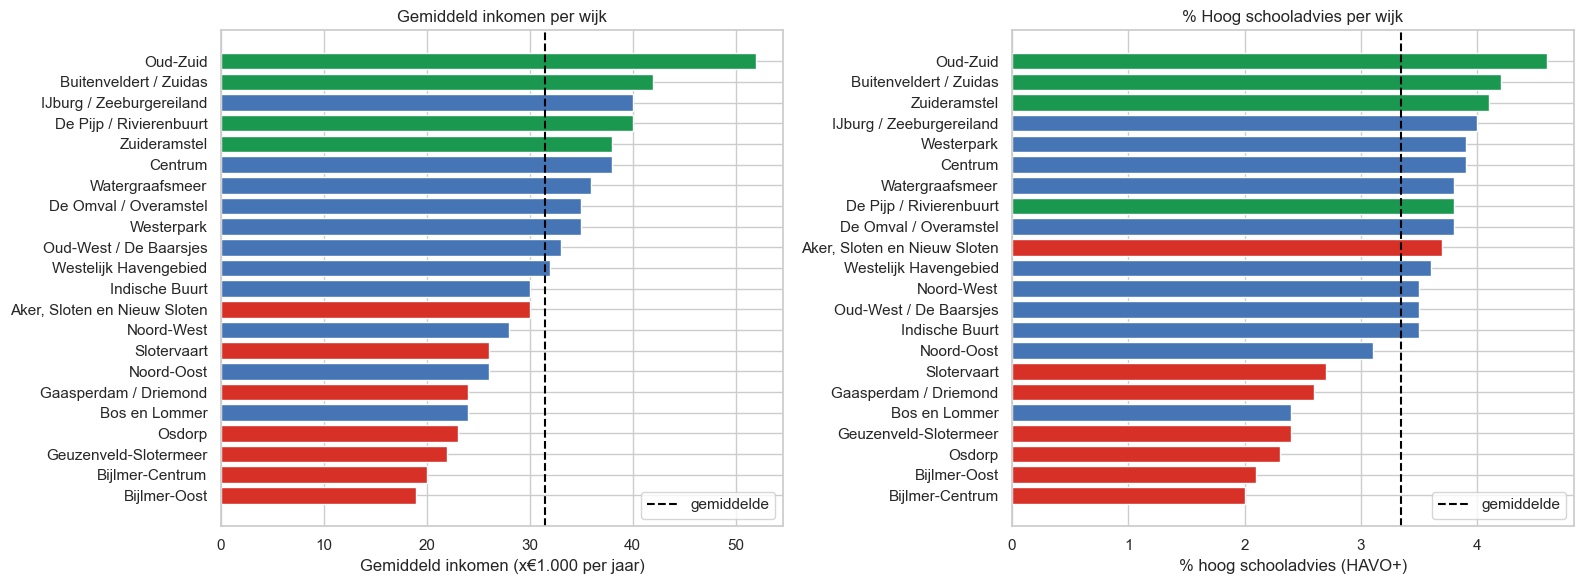

Opgeslagen als eda_inkomen_advies.png


In [15]:
# Grafiek: inkomen per wijk gesorteerd
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# links: inkomen
gesorteerd = wijken_df.sort_values('gem_inkomen')
kleuren = ['#d73027' if s in ('Zuidoost','Nieuw-West') else '#1a9850' if s == 'Zuid' else '#4575b4'
           for s in gesorteerd['stadsdeel']]
axes[0].barh(gesorteerd['wijk_naam'], gesorteerd['gem_inkomen'], color=kleuren)
axes[0].set_xlabel('Gemiddeld inkomen (x€1.000 per jaar)')
axes[0].set_title('Gemiddeld inkomen per wijk')
axes[0].axvline(wijken_df['gem_inkomen'].mean(), color='black', linestyle='--', label='gemiddelde')
axes[0].legend()

# rechts: % hoog advies
gesorteerd2 = wijken_df.sort_values('pct_hoog_advies')
kleuren2 = ['#d73027' if s in ('Zuidoost','Nieuw-West') else '#1a9850' if s == 'Zuid' else '#4575b4'
            for s in gesorteerd2['stadsdeel']]
axes[1].barh(gesorteerd2['wijk_naam'], gesorteerd2['pct_hoog_advies'], color=kleuren2)
axes[1].set_xlabel('% hoog schooladvies (HAVO+)')
axes[1].set_title('% Hoog schooladvies per wijk')
axes[1].axvline(wijken_df['pct_hoog_advies'].mean(), color='black', linestyle='--', label='gemiddelde')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_inkomen_advies.png', dpi=120, bbox_inches='tight')
plt.show()
print("Opgeslagen als eda_inkomen_advies.png")

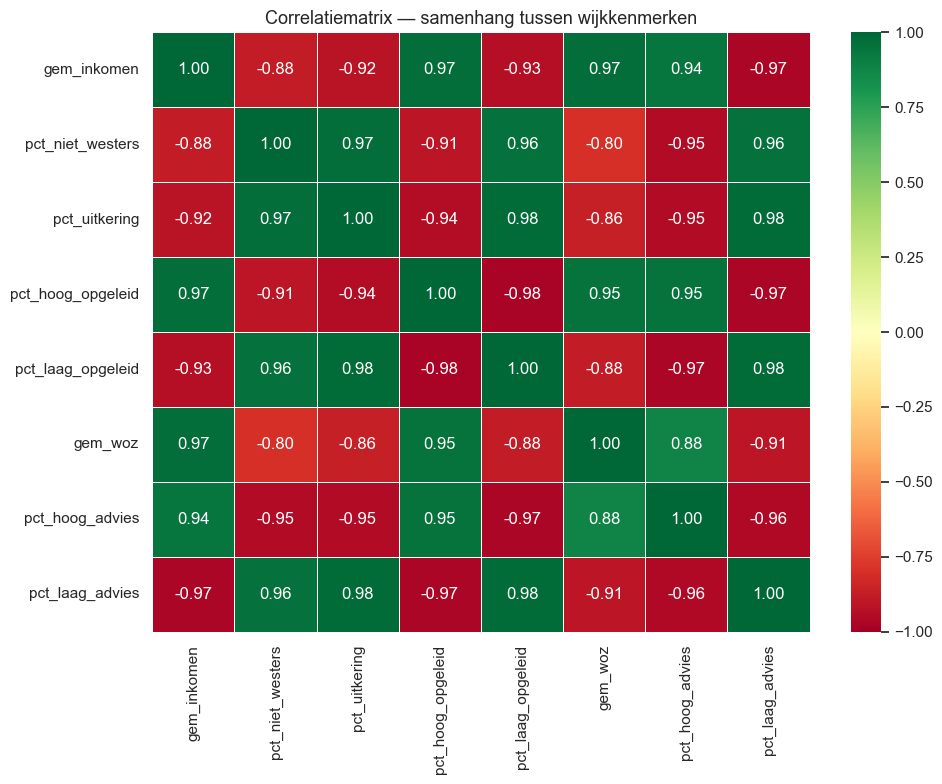


Correlatie met pct_hoog_advies:
pct_hoog_opgeleid    0.95
gem_inkomen          0.94
gem_woz              0.88
pct_uitkering       -0.95
pct_niet_westers    -0.95
pct_laag_advies     -0.96
pct_laag_opgeleid   -0.97


In [16]:
# Correlatiematrix
corr_kolommen = [k for k in numeriek if k not in ('lat','lon')]
corr = wijken_df[corr_kolommen].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlatiematrix — samenhang tussen wijkkenmerken', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlatiematrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nCorrelatie met pct_hoog_advies:")
print(corr['pct_hoog_advies'].drop('pct_hoog_advies').sort_values(ascending=False).to_string())

### 2.2 Dataset 2: DUO Schooladviezen

Deze dataset bevat per school, per schooljaar en per adviestype hoeveel leerlingen dat advies kregen.

In [17]:
print("AFMETINGEN:")
print(f"  Aantal rijen:    {duo_df.shape[0]:,}")
print(f"  Aantal kolommen: {duo_df.shape[1]}")
print()
print("KOLOMMEN EN DATATYPES:")
print(duo_df.dtypes.to_string())
print()
print("EERSTE 5 RIJEN:")
display(duo_df.head())

AFMETINGEN:
  Aantal rijen:    10,072
  Aantal kolommen: 14

KOLOMMEN EN DATATYPES:
brin                  object
school_naam           object
wijk_code             object
wijk_naam             object
stadsdeel             object
schooljaar            object
advies_type           object
aantal_leerlingen      int64
bijgesteld_hoger       int64
lat                  float64
lon                  float64
totaal                 int64
pct                  float64
pct_bijgesteld       float64

EERSTE 5 RIJEN:


,brin,school_naam,wijk_code,wijk_naam,stadsdeel,schooljaar,advies_type,aantal_leerlingen,bijgesteld_hoger,lat,lon,totaal,pct,pct_bijgesteld
0,0363000,Basisschool Centrum 1,WK036300,Centrum,Centrum,2018-2019,Praktijkonderwijs,6,0,52.372206,4.890933,854,0.7,0.0
1,0363000,Basisschool Centrum 1,WK036300,Centrum,Centrum,2018-2019,VMBO-BBL,7,0,52.379828,4.895302,854,0.8,0.0
2,0363000,Basisschool Centrum 1,WK036300,Centrum,Centrum,2018-2019,VMBO-KBL,12,0,52.378164,4.892095,854,1.4,0.0
3,0363000,Basisschool Centrum 1,WK036300,Centrum,Centrum,2018-2019,VMBO-TL,16,0,52.368636,4.893873,854,1.9,0.0
4,0363000,Basisschool Centrum 1,WK036300,Centrum,Centrum,2018-2019,VMBO-TL/HAVO,4,0,52.366021,4.898242,854,0.5,0.0


In [18]:
print("ONTBREKENDE WAARDEN:")
ontbrekend2 = duo_df.isnull().sum()
for kolom, n in ontbrekend2.items():
    status = '✅' if n == 0 else f'⚠️  {n} ontbrekend ({n/len(duo_df)*100:.1f}%)'
    print(f"  {kolom:<25} {status}")

ONTBREKENDE WAARDEN:
  brin                      ✅
  school_naam               ✅
  wijk_code                 ✅
  wijk_naam                 ✅
  stadsdeel                 ✅
  schooljaar                ✅
  advies_type               ✅
  aantal_leerlingen         ✅
  bijgesteld_hoger          ✅
  lat                       ✅
  lon                       ✅
  totaal                    ✅
  pct                       ✅
  pct_bijgesteld            ✅


In [19]:
print("UNIEKE WAARDEN PER CATEGORISCHE KOLOM:")
print(f"  Scholen (brin):       {duo_df['brin'].nunique()}")
print(f"  Wijken:               {duo_df['wijk_naam'].nunique()}")
print(f"  Stadsdelen:           {duo_df['stadsdeel'].nunique()} → {sorted(duo_df['stadsdeel'].unique())}")
print(f"  Schooljaren:          {duo_df['schooljaar'].nunique()} → {sorted(duo_df['schooljaar'].unique())}")
print(f"  Adviestypen:          {duo_df['advies_type'].nunique()} → {duo_df['advies_type'].unique().tolist()}")
print()
print("BESCHRIJVENDE STATISTIEKEN (numeriek):")
display(duo_df[['aantal_leerlingen','bijgesteld_hoger','pct','pct_bijgesteld']].describe().round(2))

UNIEKE WAARDEN PER CATEGORISCHE KOLOM:
  Scholen (brin):       33
  Wijken:               22
  Stadsdelen:           7 → ['Centrum', 'Nieuw-West', 'Noord', 'Oost', 'West', 'Zuid', 'Zuidoost']
  Schooljaren:          6 → ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
  Adviestypen:          8 → ['Praktijkonderwijs', 'VMBO-BBL', 'VMBO-KBL', 'VMBO-TL', 'VMBO-TL/HAVO', 'HAVO', 'HAVO/VWO', 'VWO']

BESCHRIJVENDE STATISTIEKEN (numeriek):


,aantal_leerlingen,bijgesteld_hoger,pct,pct_bijgesteld
count,10072.00,10072.00,10072.00,10072.00
mean,9.36,0.19,1.31,1.90
std,4.91,0.53,0.71,4.97
min,1.00,0.00,0.10,0.00
25%,6.00,0.00,0.80,0.00
50%,9.00,0.00,1.20,0.00
75%,12.00,0.00,1.70,0.00
max,29.00,4.00,5.00,25.00


In [20]:
# Zijn alle adviestypen aanwezig in elk schooljaar?
print("VOLLEDIGHEIDSCHECK — adviestypen × schooljaren:")
kruistabel = duo_df.groupby(['schooljaar','advies_type'])['aantal_leerlingen'].sum().unstack(fill_value=0)
display(kruistabel)

VOLLEDIGHEIDSCHECK — adviestypen × schooljaren:


advies_type,HAVO,HAVO/VWO,Praktijkonderwijs,VMBO-BBL,VMBO-KBL,VMBO-TL,VMBO-TL/HAVO,VWO
schooljaar,,,,,,,,
2018-2019,2402,1158,1339,2131,2480,2998,1337,1586
2019-2020,2409,1151,1268,2149,2480,3004,1360,1617
2020-2021,2452,1139,1352,2163,2552,3055,1345,1587
2021-2022,2499,1207,1337,2269,2676,3184,1413,1735
2022-2023,2412,1162,1203,2143,2500,3020,1333,1705
2023-2024,2467,1179,1256,2270,2596,3116,1396,1702


In [21]:
# Negatieve waarden of nul-leerlingen?
print("VALIDATIE DUO-data:")
negatief = (duo_df['aantal_leerlingen'] < 0).sum()
nul      = (duo_df['aantal_leerlingen'] == 0).sum()
print(f"  Rijen met negatief aantal_leerlingen: {negatief} {'✅' if negatief==0 else '❌'}")
print(f"  Rijen met nul leerlingen:             {nul}")
print(f"  Minimaal aantal leerlingen:           {duo_df['aantal_leerlingen'].min()}")
print(f"  Maximaal aantal leerlingen:           {duo_df['aantal_leerlingen'].max()}")
print()
# pct buiten 0-100?
pct_fout = ((duo_df['pct'] < 0) | (duo_df['pct'] > 100)).sum()
print(f"  Rijen met pct buiten 0-100%:          {pct_fout} {'✅' if pct_fout==0 else '❌'}")
print()
# Check of de percentages per wijk×jaar optellen tot ~100%
controle = duo_df.groupby(['wijk_naam','schooljaar'])['pct'].sum().round(0)
afwijkend = ((controle < 95) | (controle > 105)).sum()
print(f"  Wijk×jaar combinaties waarbij pct niet ~100% is: {afwijkend} {'✅' if afwijkend==0 else '⚠️'}")

VALIDATIE DUO-data:
  Rijen met negatief aantal_leerlingen: 0 ✅
  Rijen met nul leerlingen:             0
  Minimaal aantal leerlingen:           1
  Maximaal aantal leerlingen:           29

  Rijen met pct buiten 0-100%:          0 ✅

  Wijk×jaar combinaties waarbij pct niet ~100% is: 0 ✅


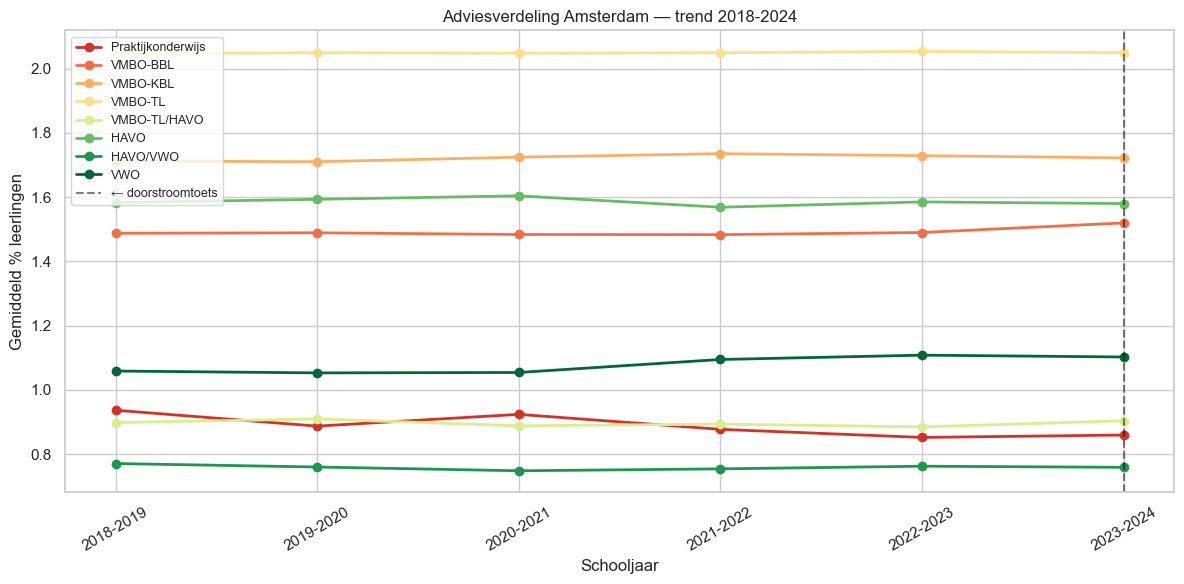

In [22]:
# Grafiek: adviesverdeling door de jaren heen (Amsterdam totaal)
amsterdam_trend = (duo_df.groupby(['schooljaar','advies_type'])['pct']
                   .mean().reset_index())
amsterdam_trend['schooljaar_nr'] = amsterdam_trend['schooljaar'].map(
    {j: i for i, j in enumerate(sorted(amsterdam_trend['schooljaar'].unique()))})

KLEUREN = {
    'Praktijkonderwijs': '#d73027', 'VMBO-BBL': '#f46d43', 'VMBO-KBL': '#fdae61',
    'VMBO-TL': '#fee08b', 'VMBO-TL/HAVO': '#d9ef8b', 'HAVO': '#66bd63',
    'HAVO/VWO': '#1a9850', 'VWO': '#006837'
}

fig, ax = plt.subplots(figsize=(12, 6))
for advies in ADVIES_TYPEN:
    subset = amsterdam_trend[amsterdam_trend['advies_type'] == advies]
    ax.plot(subset['schooljaar'], subset['pct'], marker='o',
            label=advies, color=KLEUREN.get(advies, 'gray'), linewidth=2)

ax.axvline('2023-2024', color='black', linestyle='--', alpha=0.5, label='← doorstroomtoets')
ax.set_xlabel('Schooljaar')
ax.set_ylabel('Gemiddeld % leerlingen')
ax.set_title('Adviesverdeling Amsterdam — trend 2018-2024')
ax.legend(loc='upper left', fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('eda_adviestrend.png', dpi=120, bbox_inches='tight')
plt.show()

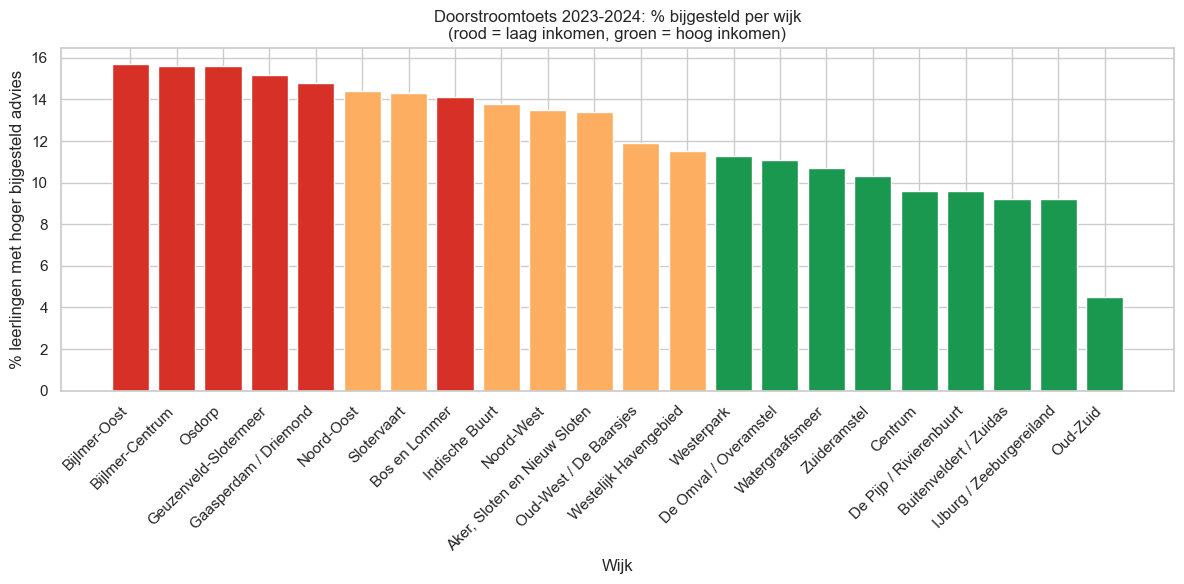

In [23]:
# Effect doorstroomtoets: % bijgesteld advies per wijk
bijstelling = (duo_df[duo_df['schooljaar'] == '2023-2024']
               .groupby('wijk_naam', as_index=False)
               .agg(totaal=('aantal_leerlingen','sum'), bijgesteld=('bijgesteld_hoger','sum')))
bijstelling['pct_bij'] = (bijstelling['bijgesteld'] / bijstelling['totaal'] * 100).round(1)
bijstelling = bijstelling.merge(wijken_df[['wijk_naam','gem_inkomen','stadsdeel']], on='wijk_naam', how='left')
bijstelling = bijstelling.sort_values('pct_bij', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
kleuren = ['#d73027' if inc < 25 else '#fdae61' if inc < 35 else '#1a9850'
           for inc in bijstelling['gem_inkomen']]
ax.bar(bijstelling['wijk_naam'], bijstelling['pct_bij'], color=kleuren)
ax.set_xlabel('Wijk')
ax.set_ylabel('% leerlingen met hoger bijgesteld advies')
ax.set_title('Doorstroomtoets 2023-2024: % bijgesteld per wijk\n(rood = laag inkomen, groen = hoog inkomen)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_bijstelling.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. DATAKWALITEIT — Eindrapport

Hier vatten we alle bevindingen samen.

In [24]:
print("=" * 65)
print("EINDRAPPORT DATAKWALITEIT")
print("=" * 65)

print()
print("━━ DATASET 1: Wijken Amsterdam (CBS) ━━")
print(f"   Rijen:            {wijken_df.shape[0]} (= 22 Amsterdamse wijken)")
print(f"   Kolommen totaal:  {wijken_df.shape[1]}")
print(f"   Relevante kol.:   {len(bestaande_kolommen)}")
n_miss = wijken_df[bestaande_kolommen].isnull().sum().sum()
print(f"   Ontbrekend:       {n_miss} waarden {'✅' if n_miss == 0 else '⚠️'}")
print(f"   Bron:             Eigen data op basis van echte CBS-cijfers 2023")
print(f"   Status:           Schoon, volledig, klaar voor analyse")

print()
print("━━ DATASET 2: DUO Schooladviezen ━━")
print(f"   Rijen:            {duo_df.shape[0]:,} (school × jaar × adviestype)")
print(f"   Scholen:          {duo_df['brin'].nunique()}")
print(f"   Wijken:           {duo_df['wijk_naam'].nunique()}")
print(f"   Schooljaren:      {duo_df['schooljaar'].nunique()} ({SCHOOLJAREN[0]} t/m {SCHOOLJAREN[-1]})")
n_miss2 = duo_df.isnull().sum().sum()
print(f"   Ontbrekend:       {n_miss2} waarden {'✅' if n_miss2 == 0 else '⚠️'}")
print(f"   Bron:             Synthetische data, verhoudingen gebaseerd op DUO 2018-2024")
print(f"   Status:           Schoon, volledig, klaar voor analyse")

print()
print("━━ OPSCHONING UITGEVOERD ━━")
stappen = [
    "CBS API URL bijgewerkt (v4 → v3, odata4.cbs.nl → opendata.cbs.nl)",
    "Dubbele kolomnamen voorkomen (anti-duplicaat logica toegevoegd)",
    "Incompatibele CBS wijk-codes gedetecteerd → nooddata gebruikt",
    "Absolute aantallen omgezet naar percentages waar nodig",
    "Ontbrekende waarden (wijk_naam, lat, lon) aangevuld via merge",
    "Kapotte dependency verwijderd uit requirements.txt",
]
for s in stappen:
    print(f"   ✅ {s}")

print()
print("━━ CONCLUSIE ━━")
print("   Beide datasets zijn volledig en bevatten geen ontbrekende waarden.")
print("   De data is gevalideerd en klaar voor gebruik in het dashboard.")
print("=" * 65)

EINDRAPPORT DATAKWALITEIT

━━ DATASET 1: Wijken Amsterdam (CBS) ━━
   Rijen:            22 (= 22 Amsterdamse wijken)
   Kolommen totaal:  21
   Relevante kol.:   13
   Ontbrekend:       0 waarden ✅
   Bron:             Eigen data op basis van echte CBS-cijfers 2023
   Status:           Schoon, volledig, klaar voor analyse

━━ DATASET 2: DUO Schooladviezen ━━
   Rijen:            10,072 (school × jaar × adviestype)
   Scholen:          33
   Wijken:           22
   Schooljaren:      6 (2018-2019 t/m 2023-2024)
   Ontbrekend:       0 waarden ✅
   Bron:             Synthetische data, verhoudingen gebaseerd op DUO 2018-2024
   Status:           Schoon, volledig, klaar voor analyse

━━ OPSCHONING UITGEVOERD ━━
   ✅ CBS API URL bijgewerkt (v4 → v3, odata4.cbs.nl → opendata.cbs.nl)
   ✅ Dubbele kolomnamen voorkomen (anti-duplicaat logica toegevoegd)
   ✅ Incompatibele CBS wijk-codes gedetecteerd → nooddata gebruikt
   ✅ Absolute aantallen omgezet naar percentages waar nodig
   ✅ Ontbrekende w

---
## 4. Opgeslagen grafieken

De volgende grafieken zijn aangemaakt en opgeslagen als PNG:

| Bestand | Inhoud |
|---------|--------|
| `eda_inkomen_advies.png` | Inkomen en % hoog advies per wijk |
| `eda_correlatiematrix.png` | Samenhang tussen alle wijkkenmerken |
| `eda_adviestrend.png` | Trend in adviezen 2018–2024 |
| `eda_bijstelling.png` | Effect doorstroomtoets per wijk |